Testing Step Size: h = 0.05
Eigenvalues: [0.95+0.15j 0.95-0.15j]
Magnitudes: [0.9617692 0.9617692]
Solution is Stable

Testing Step Size: h = 0.25
Eigenvalues: [0.75+0.75j 0.75-0.75j]
Magnitudes: [1.06066017 1.06066017]
Solution may not be Entirely Stable 



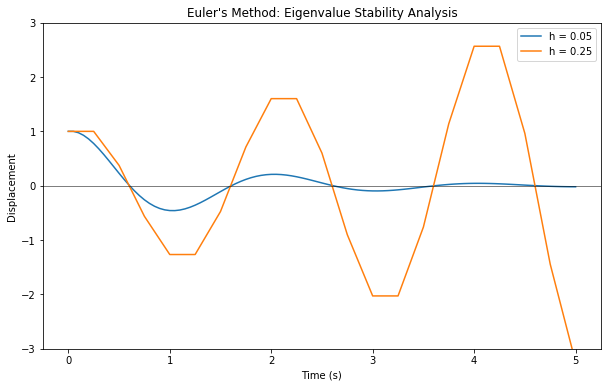

In [5]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[0.0, 1.0],
              [-10.0, -2.0]])

t_end = 5.0
y0 = np.array([1.0, 0.0]) 

step_sizes = [0.05, 0.25]

plt.figure(figsize=(10, 6))

for h in step_sizes:
    print(f"Testing Step Size: h = {h}")
    
    I = np.eye(2)
    M = I + h * A
    
    eigenvalues = np.linalg.eigvals(M)
    magnitudes = np.abs(eigenvalues)
    
    print(f"Eigenvalues: {eigenvalues}")
    print(f"Magnitudes: {magnitudes}")
    
    if np.all(magnitudes <= 1.0 + 1e-10):
        print("Solution is Stable\n")
    else:
        print("Solution may not be Entirely Stable \n")
        
    num_steps = int(t_end / h)
    t_values = np.linspace(0, t_end, num_steps + 1)
    
    y_values = np.zeros((num_steps + 1, 2))
    y_values[0] = y0
    
    for i in range(num_steps):
        y_values[i+1] = M @ y_values[i]
        
    plt.plot(t_values, y_values[:, 0], label=f'h = {h}')

plt.title("Euler's Method: Eigenvalue Stability Analysis")
plt.xlabel("Time (s)")
plt.ylabel("Displacement")
plt.axhline(0, color='black', linewidth=0.5)

plt.ylim(-3, 3) 
plt.legend()
plt.show()